# TFT volatility forecasting, prediction intervals and VaR backtesting

This notebook trains a **Temporal Fusion Transformer (TFT)** to forecast volatility for 50 S&P 500 stocks, then evaluates it in three ways:

1. **Forecasts:** p10 / p50 / p90 volatility forecasts on the 2023–24 test period.
2. **Prediction intervals:** calibrating the p10–p90 band with symmetric conformal prediction, conformalized quantile regression (CQR) and rolling CQR.
3. **Value-at-Risk:** turning each model's volatility forecast (EWMA, GARCH(1,1), TFT) into 1-day VaR and backtesting it with the Kupiec test, using normal and filtered historical simulation (FHS) multipliers.

**Run `Volatility_prediction.ipynb` first:** it builds `features.parquet` and `baseline_results.parquet`.

## 1. Setup
Environment detection (local or Colab), imports, and the random seed so training is repeatable.

In [ ]:
# ── Environment setup: works both locally (VS Code) and on Google Colab ──────
import sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Colab starts each session with a fresh machine, so install packages
    # and keep data on Google Drive so it survives the session.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "arch", "pytorch-forecasting", "pytorch-lightning"], check=True)
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/vol_forecasting"
else:
    # Locally, packages come from the .venv (pip install -r backend/requirements.txt)
    # and data lives in notebooks/data/ (git-ignored).
    PROJECT_DIR = "data"

Path(PROJECT_DIR).mkdir(parents=True, exist_ok=True)
print("Running on:", "Colab" if IN_COLAB else "local machine")
print("Project directory:", Path(PROJECT_DIR).resolve())

Running on: local machine
Project directory: C:\Users\pashi\Volatality_predication\notebooks\data


In [ ]:
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

W1007 17:43:49.386000 2824 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


In [ ]:
SEED = 42
pl.seed_everything(SEED, workers=True)

Seed set to 42


42

## 2. Data and train / validation / test split
Chronological split: train up to 2021, validate on 2022, test on 2023–24. Time series are never shuffled.

In [ ]:
# PROJECT_DIR is set in the environment setup cell above
df = pd.read_parquet(f"{PROJECT_DIR}/features.parquet")
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Shape: (85750, 24)
Tickers: 50
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'company', 'sector', 'log_ret', 'real_vol', 'target', 'vol_lag1', 'vol_lag5', 'vol_lag20', 'ewma_vol', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'volume_ratio', 'vix', 'liquidity_bucket', 'time_idx']
Date range: 2018-03-01 → 2024-12-20


In [ ]:
# TFT needs string categoricals
df["ticker"]     = df["ticker"].astype(str)
df["sector"]     = df["sector"].astype(str).fillna("Unknown")
df["liquidity_bucket"] = df["liquidity_bucket"].astype(str)

# Chronological split — never shuffle for time series
TRAIN_END = "2021-12-31"
VAL_END   = "2022-12-31"
# test = 2023–2024

df["split"] = "test"
df.loc[df["date"] <= TRAIN_END, "split"] = "train"
df.loc[(df["date"] > TRAIN_END) & (df["date"] <= VAL_END), "split"] = "val"

print(df["split"].value_counts())

split
train    48400
test     24800
val      12550
Name: count, dtype: int64


## 3. Datasets and dataloaders
The TFT looks back 60 days and predicts 5 days ahead. Validation and test reuse the training set's normaliser, so no information leaks from later periods.

In [ ]:
MAX_ENCODER_LENGTH    = 60  # model looks back 60 days
MAX_PREDICTION_LENGTH = 5   # predicts 5 days ahead

train_df = df[df["split"] == "train"].copy()

training = TimeSeriesDataSet(
    train_df,
    time_idx              = "time_idx",
    target                = "target",
    group_ids             = ["ticker"],
    max_encoder_length    = MAX_ENCODER_LENGTH,
    max_prediction_length = MAX_PREDICTION_LENGTH,

    # Static — same value for all timesteps of a ticker
    static_categoricals   = ["sector", "liquidity_bucket"],
    static_reals          = [],

    # Known future — you know these values ahead of time
    time_varying_known_reals = [
        "time_idx",
        "day_sin", "day_cos",
        "month_sin", "month_cos",
    ],

    # Unknown future — only observable up to today
    time_varying_unknown_reals = [
        "real_vol",
        "vol_lag1", "vol_lag5", "vol_lag20",
        "ewma_vol",
        "vix",
        "volume_ratio",
        "log_ret",
    ],

    target_normalizer = GroupNormalizer(
        groups=["ticker"], transformation="softplus"
    ),
    add_relative_time_idx = True,
    add_target_scales     = True,
    add_encoder_length    = True,
)

# Val and test share the normalizer from training — critical, no data leakage
validation = TimeSeriesDataSet.from_dataset(
    training, df[df["split"] == "val"].copy(),
    predict=False, stop_randomization=True
)
testing = TimeSeriesDataSet.from_dataset(
    training, df[df["split"] == "test"].copy(),
    predict=False, stop_randomization=True
)

print(f"Train samples: {len(training)}")
print(f"Val samples:   {len(validation)}")
print(f"Test samples:  {len(testing)}")

Train samples: 45200
Val samples:   9350
Test samples:  21600


In [ ]:
BATCH_SIZE = 128

train_loader = training.to_dataloader(
    train=True,  batch_size=BATCH_SIZE, num_workers=2
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)
test_loader = testing.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)

# Sanity check — one batch
x, y = next(iter(train_loader))
print(f"Batch x keys:  {list(x.keys())}")
print(f"Batch y shape: {y[0].shape}")
# y shape should be (batch_size, 5) — 5 = prediction length

Batch x keys:  ['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale']
Batch y shape: torch.Size([128, 5])


## 4. Model definition and training
Quantile loss at 0.1 / 0.5 / 0.9, early stopping on validation loss, and the best checkpoint saved.

In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 1e-3,
    hidden_size            = 32,
    attention_head_size    = 2,
    dropout                = 0.1,
    hidden_continuous_size = 16,
    loss                   = QuantileLoss([0.1, 0.5, 0.9]),
    log_interval           = 10,
    optimizer              = "adam",
    reduce_on_plateau_patience = 4,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 101,061


c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [ ]:
# Uses the GPU if available (local NVIDIA GPU, or Colab: Runtime → Change runtime type → T4 GPU)
print("GPU available:", torch.cuda.is_available())

trainer = pl.Trainer(
    max_epochs        = 30,
    accelerator       = "gpu" if torch.cuda.is_available() else "cpu",
    gradient_clip_val = 0.1,
    callbacks         = [
        pl.callbacks.EarlyStopping(
            monitor  = "val_loss",
            patience = 5,
            mode     = "min"
        ),
        pl.callbacks.ModelCheckpoint(
            monitor   = "val_loss",
            dirpath   = PROJECT_DIR,
            filename  = "tft_best",
            save_top_k= 1,
            mode      = "min"
        ),
    ],
    logger = False,
    enable_progress_bar = True,
)

trainer.fit(tft, train_loader, val_loader)
print("Training complete.")
print(f"Best val loss: {trainer.checkpoint_callback.best_model_score:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\pashi\Volatality_predication\notebooks\data exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 54     | train | 0    
3  | prescalers                         | ModuleDict                      | 544    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 6.1 K  | train | 0    
5  | encoder_variable_selection         | Va

GPU available: True


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training complete.
Best val loss: 0.0394


## 5. Test-set forecasts
Loads the checkpoint the trainer actually saved in this run (not a fixed file name, which could be a stale file from an earlier run), then predicts p10 / p50 / p90 for the test period.

In [ ]:
best_path = trainer.checkpoint_callback.best_model_path
print("Loading checkpoint:", best_path)

Loading checkpoint: C:\Users\pashi\Volatality_predication\notebooks\data\tft_best-v1.ckpt


In [ ]:
best_model = TemporalFusionTransformer.load_from_checkpoint(best_path)
best_model.eval()

# Generate predictions on test set
predictions = best_model.predict(
    test_loader,
    mode         = "quantiles",
    return_index = True,
)

# predictions is a named tuple — extract parts
pred_output = predictions.output   # shape (n_samples, horizon, 3) — p10, p50, p90
pred_index  = predictions.index    # DataFrame with ticker, time_idx per sample

print(f"Prediction output shape: {pred_output.shape}")
print(f"Index shape: {pred_index.shape}")
print(f"Index columns: {pred_index.columns.tolist()}")
print(pred_index.head())

c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litm

Prediction output shape: torch.Size([21600, 5, 3])
Index shape: (21600, 2)
Index columns: ['time_idx', 'ticker']
   time_idx ticker
0      1319   AAPL
1      1320   AAPL
2      1321   AAPL
3      1322   AAPL
4      1323   AAPL


In [ ]:
p10 = pred_output[:, :, 0].numpy()  # lower bound
p50 = pred_output[:, :, 1].numpy()  # median — main forecast
p90 = pred_output[:, :, 2].numpy()  # upper bound

print(f"p50 sample (first 3 predictions, all 5 days):\n{p50[:3]}")

p50 sample (first 3 predictions, all 5 days):
[[0.18878499 0.18817748 0.18822448 0.18746544 0.18728612]
 [0.18401937 0.18515915 0.18467563 0.1849289  0.18644017]
 [0.18510078 0.18553479 0.18595083 0.18775277 0.18945242]]


## 6. Raw forecast evaluation
Coverage of the raw p10–p90 band, the RMSE / MAE comparison with the baselines from `Volatility_prediction.ipynb`, and forecast plots for three stocks.

*Note: the RMSE table is not a like-for-like comparison. The baselines are scored on same-day realised volatility from 2022 onward, the TFT on its 5-day-ahead target from 2023. The VaR backtest in section 9 compares the models fairly on identical days.*

In [ ]:
def rmse(a, p): return round(np.sqrt(mean_squared_error(a, p)), 4)
def mae(a, p):  return round(mean_absolute_error(a, p), 4)

actuals_list = []
p50_list     = []
p10_list     = []
p90_list     = []

for i in range(len(pred_index)):
    ticker   = pred_index.iloc[i]["ticker"]
    time_idx = pred_index.iloc[i]["time_idx"]

    actual_rows = df[
        (df["ticker"]   == ticker) &
        (df["time_idx"] >= time_idx) &
        (df["time_idx"] <  time_idx + MAX_PREDICTION_LENGTH)
    ]["target"].values

    pred_p50 = p50[i]
    pred_p10 = p10[i]
    pred_p90 = p90[i]

    min_len = min(len(actual_rows), len(pred_p50))
    if min_len == 0:
        continue

    actuals_list.extend(actual_rows[:min_len].tolist())
    p50_list.extend(pred_p50[:min_len].tolist())
    p10_list.extend(pred_p10[:min_len].tolist())
    p90_list.extend(pred_p90[:min_len].tolist())

actuals_arr = np.array(actuals_list)
p50_arr     = np.array(p50_list)
p10_arr     = np.array(p10_list)
p90_arr     = np.array(p90_list)

# Coverage — % of actuals that fall inside p10–p90 band
# A well calibrated model should be close to 80%
coverage = np.mean((actuals_arr >= p10_arr) & (actuals_arr <= p90_arr))
avg_width = np.mean(p90_arr - p10_arr)

print(f"Samples matched: {len(actuals_arr):,}")
print(f"Coverage (p10–p90): {coverage:.1%}  (target ~80%)")
print(f"Avg interval width: {avg_width:.4f}")

Samples matched: 108,000
Coverage (p10–p90): 63.0%  (target ~80%)
Avg interval width: 0.0829


In [ ]:
baseline = pd.read_parquet(f"{PROJECT_DIR}/baseline_results.parquet")
baseline_mean = baseline.mean(numeric_only=True).round(4)

comparison = pd.DataFrame({
    "Model": [
        "Random Walk",
        "Hist Average",
        "EWMA",
        "GARCH(1,1)",
        "TFT (p50)",
    ],
    "RMSE": [
        baseline_mean["rw_rmse"],
        baseline_mean["hist_rmse"],
        baseline_mean["ewma_rmse"],
        baseline_mean["garch_rmse"],
        rmse(actuals_arr, p50_arr),
    ],
    "MAE": [
        baseline_mean["rw_mae"],
        baseline_mean["hist_mae"],
        baseline_mean["ewma_mae"],
        baseline_mean["garch_mae"],
        mae(actuals_arr, p50_arr),
    ],
})

print("=" * 42)
print("       FINAL RESULTS TABLE")
print("=" * 42)
print(comparison.to_string(index=False))
print("=" * 42)
print(f"TFT Coverage (p10-p90): {coverage:.1%}")
print(f"TFT Avg Interval Width: {avg_width:.4f}")

       FINAL RESULTS TABLE
       Model   RMSE    MAE
 Random Walk 0.0240 0.0107
Hist Average 0.0795 0.0602
        EWMA 0.0373 0.0269
  GARCH(1,1) 0.0751 0.0558
   TFT (p50) 0.0625 0.0396
TFT Coverage (p10-p90): 63.0%
TFT Avg Interval Width: 0.0829


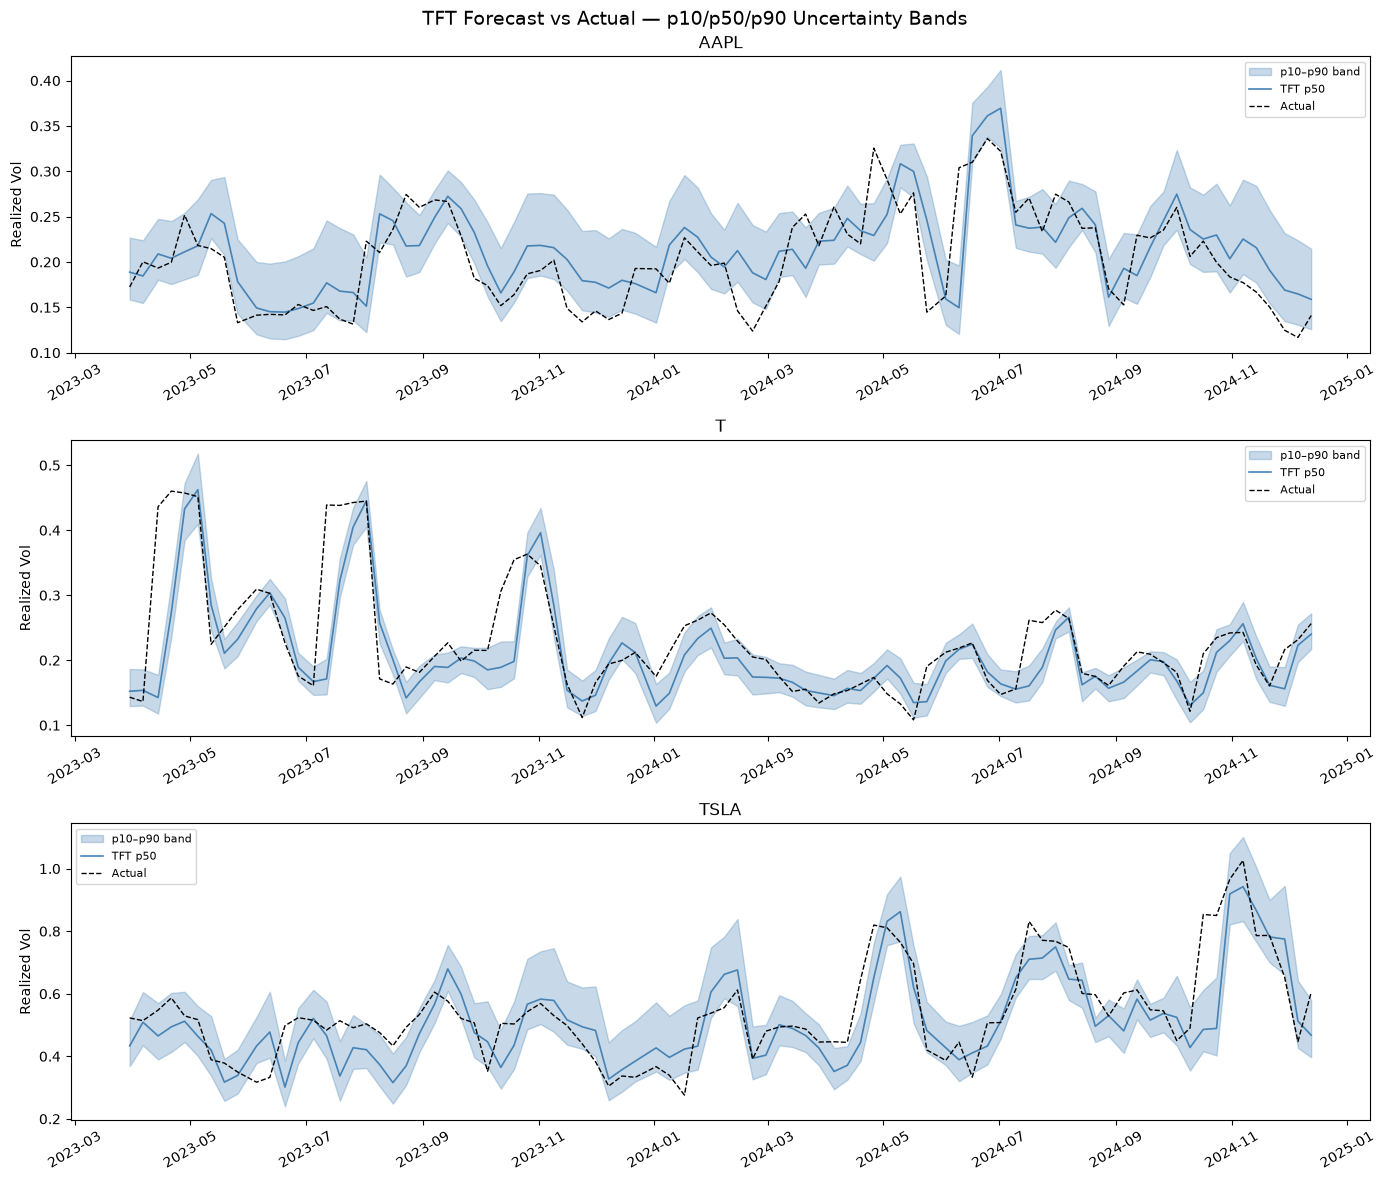

In [ ]:
tickers_to_plot = ["AAPL", "T", "TSLA"]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, ticker in zip(axes, tickers_to_plot):
    # Get all prediction indices for this ticker
    mask = pred_index["ticker"] == ticker
    ticker_positions = np.where(mask.values)[0]

    if len(ticker_positions) == 0:
        ax.set_title(f"{ticker} — no predictions found")
        continue

    # Use every 5th prediction to avoid overlapping windows
    ticker_positions = ticker_positions[::5]

    dates, actuals, p10s, p50s, p90s = [], [], [], [], []

    for i in ticker_positions:
        time_idx = pred_index.iloc[i]["time_idx"]

        actual_rows = df[
            (df["ticker"]   == ticker) &
            (df["time_idx"] == time_idx)
        ]
        if len(actual_rows) == 0:
            continue

        dates.append(actual_rows["date"].values[0])
        actuals.append(actual_rows["target"].values[0])
        p10s.append(float(p10[i, 0]))
        p50s.append(float(p50[i, 0]))
        p90s.append(float(p90[i, 0]))

    dates   = pd.to_datetime(dates)
    actuals = np.array(actuals)
    p10s    = np.array(p10s)
    p50s    = np.array(p50s)
    p90s    = np.array(p90s)

    ax.fill_between(dates, p10s, p90s,
                    alpha=0.3, color="steelblue", label="p10–p90 band")
    ax.plot(dates, p50s,    color="steelblue", lw=1.2, label="TFT p50")
    ax.plot(dates, actuals, color="black",     lw=1,   label="Actual", ls="--")
    ax.set_title(f"{ticker}")
    ax.set_ylabel("Realized Vol")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("TFT Forecast vs Actual — p10/p50/p90 Uncertainty Bands", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Model interpretation
Which inputs and which past days the TFT's attention relies on.

In [ ]:
batch = next(iter(test_loader))
best_model.eval()
with torch.no_grad():
    output = best_model(batch[0])  # batch[0] = x, batch[1] = y

interpretation = best_model.interpret_output(
    output,
    reduction="sum"
)

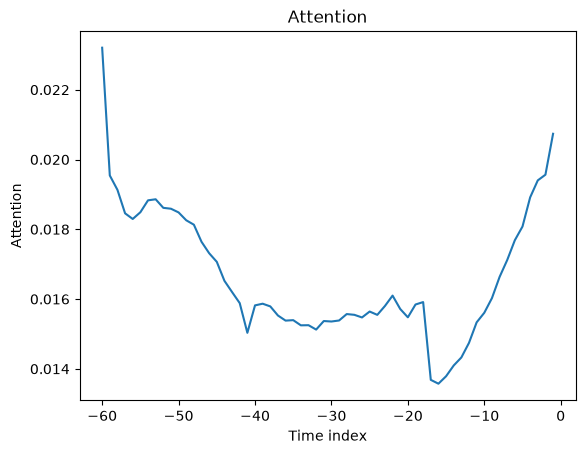

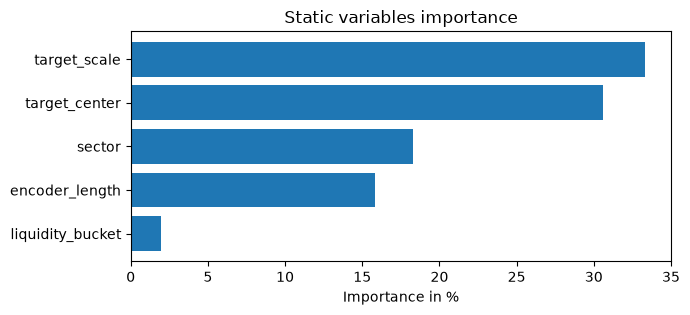

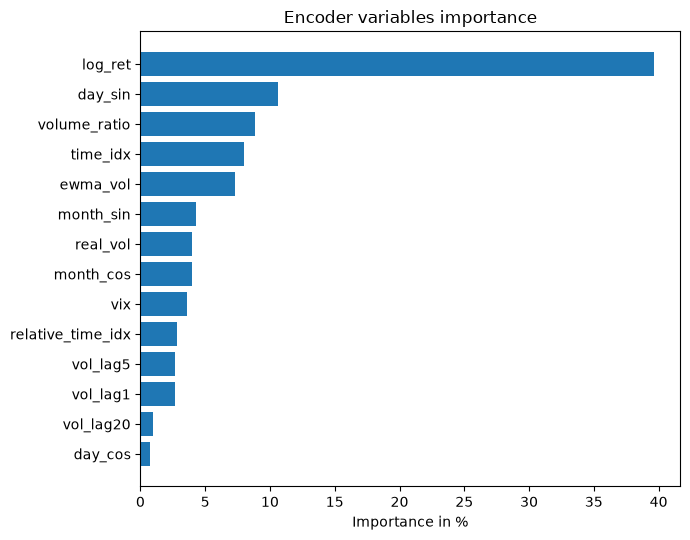

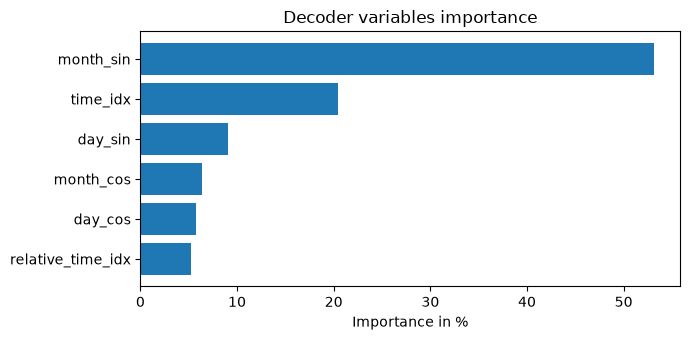

In [ ]:
best_model.plot_interpretation(interpretation)
plt.show()

## 8. Prediction intervals
The raw p10–p90 band covers too few outcomes, so it is calibrated on the 2022 validation set. Three methods, each targeting 80% coverage:

- **Symmetric conformal:** p50 ± Q, with Q the 80th percentile of validation errors.
- **CQR (conformalized quantile regression):** [p10 − Q, p90 + Q], with Q from how far validation actuals fell outside the model's own band. Keeps the band's adaptive shape.
- **Rolling CQR:** the same, but Q is re-estimated each day from the last 60 trading days of outcomes already known at forecast time, so it adapts to changing market regimes.

Good intervals reach about 80% coverage with the smallest width, and stay near 80% in every quarter.

### 8.1 Validation forecasts and errors

In [ ]:
# Step 1 — Get TFT predictions on the VALIDATION set
val_preds = best_model.predict(
    val_loader,
    mode         = "quantiles",
    return_index = True,
)

val_output = val_preds.output.numpy()   # (n, 5, 3)
val_index  = val_preds.index

val_p50 = val_output[:, :, 1]  # median predictions on val set

# Step 2 — Compute residuals on val set
val_actuals = []
val_p50_flat = []

for i in range(len(val_index)):
    ticker   = val_index.iloc[i]["ticker"]
    time_idx = val_index.iloc[i]["time_idx"]

    actual_rows = df[
        (df["ticker"]   == ticker) &
        (df["time_idx"] >= time_idx) &
        (df["time_idx"] <  time_idx + MAX_PREDICTION_LENGTH)
    ]["target"].values

    pred = val_p50[i]
    min_len = min(len(actual_rows), len(pred))
    if min_len == 0:
        continue

    val_actuals.extend(actual_rows[:min_len].tolist())
    val_p50_flat.extend(pred[:min_len].tolist())

val_actuals  = np.array(val_actuals)
val_p50_flat = np.array(val_p50_flat)

# Residuals — absolute errors on val set
residuals = np.abs(val_actuals - val_p50_flat)

print(f"Val samples: {len(residuals):,}")
print(f"Mean residual: {residuals.mean():.4f}")
print(f"80th percentile residual: {np.quantile(residuals, 0.80):.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\pashi\Volatality_predication\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'predict_dataloader' to speed up the dataloader worke

Val samples: 46,750
Mean residual: 0.0564
80th percentile residual: 0.0839


### 8.2 Symmetric conformal calibration

In [ ]:
# The conformal quantile — this is Q
# Using 80% target coverage
COVERAGE_TARGET = 0.80
Q = np.quantile(residuals, COVERAGE_TARGET)
print(f"Conformal correction Q (80%): {Q:.4f}")

# Apply to test predictions — widen or narrow TFT's intervals
# by the correction factor
conformal_lower = p50_arr - Q
conformal_upper = p50_arr + Q

# Clip lower bound at 0 — volatility can't be negative
conformal_lower = np.clip(conformal_lower, 0, None)

# New coverage
conformal_coverage = np.mean(
    (actuals_arr >= conformal_lower) &
    (actuals_arr <= conformal_upper)
)
conformal_width = np.mean(conformal_upper - conformal_lower)

print(f"\n{'':=<45}")
print(f"  BEFORE conformal:  coverage={coverage:.1%}  width={avg_width:.4f}")
print(f"  AFTER  conformal:  coverage={conformal_coverage:.1%}  width={conformal_width:.4f}")
print(f"{'':=<45}")

Conformal correction Q (80%): 0.0839

  BEFORE conformal:  coverage=63.0%  width=0.0829
  AFTER  conformal:  coverage=90.6%  width=0.1677


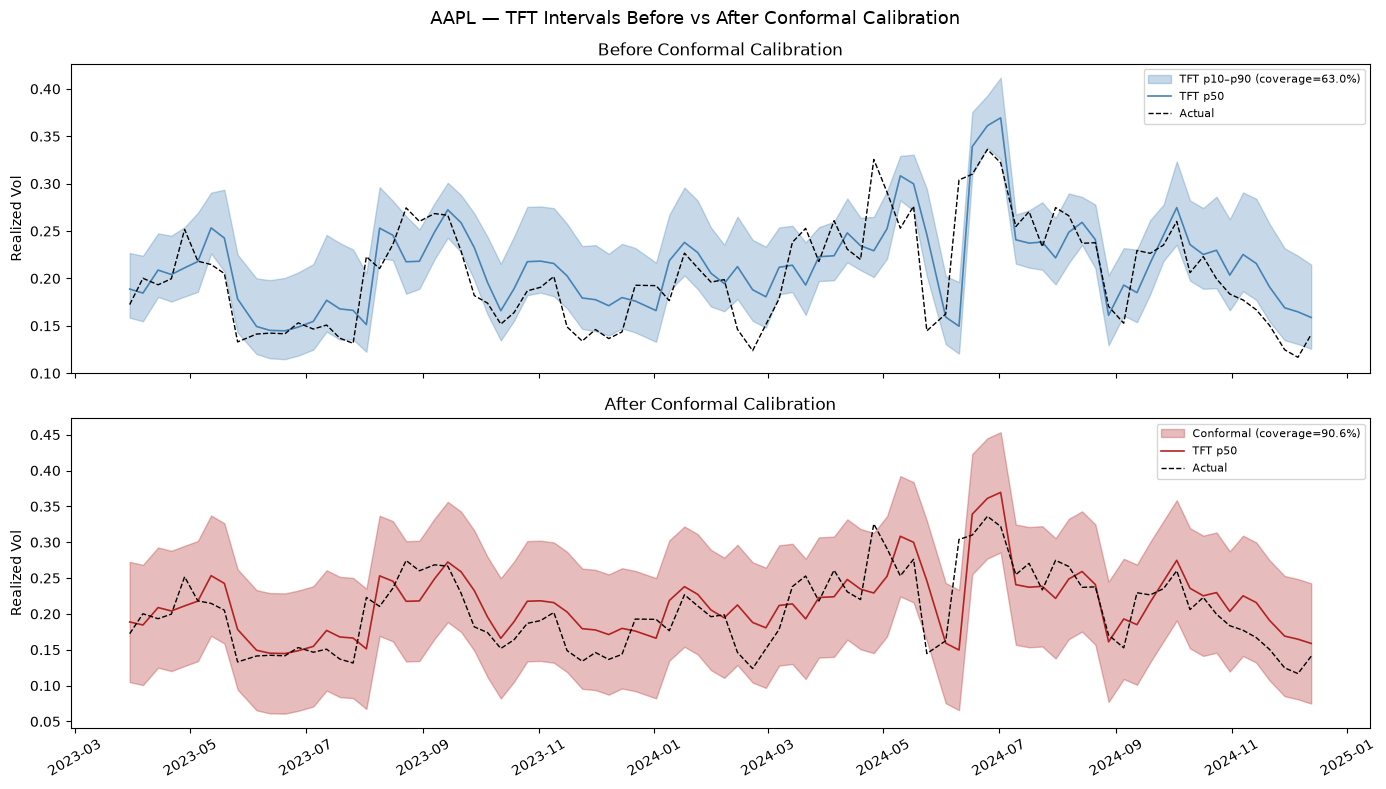

In [ ]:
ticker = "AAPL"
mask   = pred_index["ticker"] == ticker
positions = np.where(mask.values)[0][::5]

dates, acts, orig_lo, orig_hi, conf_lo, conf_hi, p50s = [], [], [], [], [], [], []

for i in positions:
    time_idx = pred_index.iloc[i]["time_idx"]
    row = df[(df["ticker"] == ticker) & (df["time_idx"] == time_idx)]
    if len(row) == 0:
        continue

    # Find position in flattened arrays
    flat_i = i  # one-to-one for first step of each prediction window

    dates.append(row["date"].values[0])
    acts.append(row["target"].values[0])
    orig_lo.append(float(p10[i, 0]))
    orig_hi.append(float(p90[i, 0]))
    conf_lo.append(max(0, float(p50[i, 0]) - Q))
    conf_hi.append(float(p50[i, 0]) + Q)
    p50s.append(float(p50[i, 0]))

dates   = pd.to_datetime(dates)
acts    = np.array(acts)
orig_lo = np.array(orig_lo)
orig_hi = np.array(orig_hi)
conf_lo = np.array(conf_lo)
conf_hi = np.array(conf_hi)
p50s    = np.array(p50s)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Original TFT intervals
ax1.fill_between(dates, orig_lo, orig_hi,
                 alpha=0.3, color="steelblue", label=f"TFT p10–p90 (coverage={coverage:.1%})")
ax1.plot(dates, p50s, color="steelblue", lw=1.2, label="TFT p50")
ax1.plot(dates, acts, color="black", lw=1, ls="--", label="Actual")
ax1.set_title("Before Conformal Calibration")
ax1.set_ylabel("Realized Vol")
ax1.legend(fontsize=8)

# Conformal intervals
ax2.fill_between(dates, conf_lo, conf_hi,
                 alpha=0.3, color="firebrick", label=f"Conformal (coverage={conformal_coverage:.1%})")
ax2.plot(dates, p50s, color="firebrick", lw=1.2, label="TFT p50")
ax2.plot(dates, acts, color="black", lw=1, ls="--", label="Actual")
ax2.set_title("After Conformal Calibration")
ax2.set_ylabel("Realized Vol")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=30)

plt.suptitle("AAPL — TFT Intervals Before vs After Conformal Calibration", fontsize=13)
plt.tight_layout()
plt.show()

### 8.3 Conformalized quantile regression (fixed, calibrated on 2022)

In [ ]:
# Conformalized Quantile Regression (Romano et al., 2019)
# Score = how far the actual fell outside the model's own p10-p90 band
#         (negative if inside). Q is the conformal quantile of those scores.

# Validation actuals and p10/p90, flattened the same way as the test set
v_act, v_lo, v_hi = [], [], []
for i in range(len(val_index)):
    t, ti = val_index.iloc[i]["ticker"], val_index.iloc[i]["time_idx"]
    a = df[(df["ticker"] == t) & (df["time_idx"] >= ti) &
           (df["time_idx"] < ti + MAX_PREDICTION_LENGTH)]["target"].values
    n = min(len(a), MAX_PREDICTION_LENGTH)
    v_act.extend(a[:n]); v_lo.extend(val_output[i, :n, 0]); v_hi.extend(val_output[i, :n, 2])
v_act, v_lo, v_hi = map(np.array, (v_act, v_lo, v_hi))

scores = np.maximum(v_lo - v_act, v_act - v_hi)
n_cal  = len(scores)
level  = np.ceil((n_cal + 1) * COVERAGE_TARGET) / n_cal     # finite-sample correction
Q_cqr  = np.quantile(scores, min(level, 1.0))

cqr_lower = np.clip(p10_arr - Q_cqr, 0, None)
cqr_upper = p90_arr + Q_cqr
cqr_coverage = np.mean((actuals_arr >= cqr_lower) & (actuals_arr <= cqr_upper))
cqr_width    = np.mean(cqr_upper - cqr_lower)

print(f"Validation coverage of raw band: {np.mean((v_act >= v_lo) & (v_act <= v_hi)):.1%}")
print(f"CQR correction Q: {Q_cqr:+.4f}")
print(f"  RAW band:           coverage={coverage:.1%}  width={avg_width:.4f}")
print(f"  Symmetric conformal: coverage={conformal_coverage:.1%}  width={conformal_width:.4f}")
print(f"  CQR:                coverage={cqr_coverage:.1%}  width={cqr_width:.4f}")

Validation coverage of raw band: 54.2%
CQR correction Q: +0.0325
  RAW band:           coverage=63.0%  width=0.0829
  Symmetric conformal: coverage=90.6%  width=0.1677
  CQR:                coverage=89.2%  width=0.1480


### 8.4 Rolling-window CQR

In [ ]:
# ── Rolling-window CQR ────────────────────────────────────────────────────────
# Each forecast's correction Q is the conformal quantile of CQR scores from the
# last WINDOW trading days whose outcome was ALREADY KNOWN at forecast time.
# The target (20-day realised vol, 5 days ahead) is known 5 trading days after
# its row date, and a forecast for horizon step h was made h+1 days before it.
# The window starts in the 2022 validation data, so all of 2023-24 is covered.
WINDOW  = 60     # trading days (~3 months) — fixed in advance, not tuned on test
KNOWN_LAG = 5    # target known 5 trading days after its row date

to_np = lambda x: x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)
H = MAX_PREDICTION_LENGTH

def flatten_points(index, lo, mid, hi):
    """One row per (window, horizon step) with date, actual target and quantiles."""
    p = index[["ticker", "time_idx"]].reset_index(drop=True)
    p = p.loc[p.index.repeat(H)].reset_index(drop=True)
    p["h"] = np.tile(np.arange(H), len(index))
    p["time_idx"] = p["time_idx"] + p["h"]
    p["p10"], p["p50"], p["p90"] = to_np(lo).reshape(-1), to_np(mid).reshape(-1), to_np(hi).reshape(-1)
    return p.merge(df[["ticker", "time_idx", "date", "target"]], on=["ticker", "time_idx"], how="inner")

val_pts  = flatten_points(val_index, val_output[:, :, 0], val_output[:, :, 1], val_output[:, :, 2])
test_pts = flatten_points(pred_index, p10, p50, p90)

# Global trading-day number for every date
all_days = np.sort(pd.concat([val_pts["date"], test_pts["date"]]).unique())
day_num  = pd.Series(np.arange(len(all_days)), index=all_days)
for p in (val_pts, test_pts):
    p["g"]      = day_num.loc[p["date"]].values
    p["known"]  = p["g"] + KNOWN_LAG          # day the outcome becomes known
    p["origin"] = p["g"] - p["h"] - 1         # day the forecast was made
    p["score"]  = np.maximum(p["p10"] - p["target"], p["target"] - p["p90"])

# Pool of past scores (validation + test), sorted by the day they became known
pool = pd.concat([val_pts, test_pts])[["known", "score"]].sort_values("known")
known_days, pool_scores = pool["known"].values, pool["score"].values

def rolling_q(origin):
    lo = np.searchsorted(known_days, origin - WINDOW, side="right")
    hi = np.searchsorted(known_days, origin, side="right")      # known by origin
    s = pool_scores[lo:hi]
    n = len(s)
    return np.quantile(s, min(np.ceil((n + 1) * COVERAGE_TARGET) / n, 1.0)) if n else np.nan

q_by_origin = {o: rolling_q(o) for o in np.unique(test_pts["origin"])}
test_pts["Q"] = test_pts["origin"].map(q_by_origin)

lo_r = np.clip(test_pts["p10"] - test_pts["Q"], 0, None)
hi_r = test_pts["p90"] + test_pts["Q"]
inside = (test_pts["target"] >= lo_r) & (test_pts["target"] <= hi_r)

# Fixed CQR (calibrated once on 2022) on exactly the same points, for comparison
Q_fixed = np.quantile(val_pts["score"], min(np.ceil((len(val_pts) + 1) * COVERAGE_TARGET) / len(val_pts), 1.0))
lo_f = np.clip(test_pts["p10"] - Q_fixed, 0, None); hi_f = test_pts["p90"] + Q_fixed
inside_f = (test_pts["target"] >= lo_f) & (test_pts["target"] <= hi_f)
raw_in = (test_pts["target"] >= test_pts["p10"]) & (test_pts["target"] <= test_pts["p90"])

print(f"Test points: {len(test_pts):,}   window: {WINDOW} days   Q range: "
      f"{test_pts['Q'].min():+.4f} to {test_pts['Q'].max():+.4f}")
print(f"  Raw TFT band          coverage={raw_in.mean():6.1%}  width={np.mean(test_pts.p90 - test_pts.p10):.4f}")
print(f"  CQR fixed (2022)      coverage={inside_f.mean():6.1%}  width={np.mean(hi_f - lo_f):.4f}")
print(f"  CQR rolling ({WINDOW}d)    coverage={inside.mean():6.1%}  width={np.mean(hi_r - lo_r):.4f}")

# Coverage by quarter — rolling should stay near 80% throughout
by_q = pd.DataFrame({"q": test_pts["date"].dt.to_period("Q"), "fixed": inside_f, "rolling": inside})
print("\nCoverage by quarter:")
print(by_q.groupby("q")[["fixed", "rolling"]].mean().map(lambda v: f"{v:.1%}").to_string())

Test points: 108,000   window: 60 days   Q range: +0.0079 to +0.0289
  Raw TFT band          coverage= 63.0%  width=0.0829
  CQR fixed (2022)      coverage= 89.2%  width=0.1480
  CQR rolling (60d)    coverage= 80.1%  width=0.1158

Coverage by quarter:
        fixed rolling
q                    
2023Q1  95.3%   91.3%
2023Q2  90.3%   84.7%
2023Q3  92.9%   80.2%
2023Q4  91.6%   78.1%
2024Q1  91.4%   80.2%
2024Q2  85.8%   75.4%
2024Q3  83.3%   79.4%
2024Q4  89.3%   82.8%


## 9. 1-day VaR backtest (Kupiec POF test)
Turns each model's volatility forecast into a 1-day Value-at-Risk and checks how often actual returns breached it. All models are scored on the same tickers and the same 2023–24 dates as the TFT test predictions, using only information available the day before.

**Forecast alignment.** The target is 20-day realised volatility shifted 5 days ahead, and the TFT's encoder receives past target values, so a forecast window has effectively seen returns up to 4 days after its other inputs end. Each TFT forecast is therefore dated from the last day the model had information for, and used as a 1-day-ahead σ for the following day (cell V2). EWMA and GARCH use only returns before the day being forecast.

In [ ]:
# CELL V1 - setup
import numpy as np
import pandas as pd
from scipy.stats import norm, chi2
from arch import arch_model

ALPHAS = [0.01, 0.05]          # 99% and 95% VaR
SQRT252 = np.sqrt(252)


In [ ]:
# CELL V2 - daily sigma forecasts for every model (no look-ahead)
d = df.sort_values(["ticker", "time_idx"]).copy()

# EWMA: ewma_vol on day t already includes day t's return, so use yesterday's value
d["sig_ewma"] = d.groupby("ticker")["ewma_vol"].shift(1) / SQRT252

# TFT: "target" is real_vol shifted 5 days forward, and the encoder is fed past target
# values. So a forecast whose first decoder step is time_idx = k has already seen
# real_vol(k+4), i.e. returns up to day k+4. Its step-0 output predicts real_vol(k+5),
# whose only unseen return is day k+5. So it is a valid 1-day-ahead forecast for day k+5.
TARGET_SHIFT = 5
tft_sig = pd.DataFrame({
    "ticker":   pred_index["ticker"].astype(str).values,
    "time_idx": pred_index["time_idx"].astype(int).values + TARGET_SHIFT,
    "sig_tft":  p50[:, 0] / SQRT252,          # annualised vol -> daily sigma
})
d = d.merge(tft_sig, on=["ticker", "time_idx"], how="left")

# GARCH(1,1): refit every 20 days, but update the variance every day with the latest return
def garch_sigma(log_ret, eval_pos, refit_every=20):
    r = np.asarray(log_ret, dtype=float) * 100
    out = np.full(len(r), np.nan)
    params = None
    for n, pos in enumerate(eval_pos):
        hist = r[:pos]                       # returns strictly before the forecast day
        if params is None or n % refit_every == 0:
            params = arch_model(hist, mean="Zero", vol="GARCH", p=1, q=1).fit(disp="off").params
        fc = arch_model(hist, mean="Zero", vol="GARCH", p=1, q=1).fix(params).forecast(horizon=1, reindex=False)
        out[pos] = np.sqrt(fc.variance.values[-1, 0]) / 100
    return out

d["sig_garch"] = np.nan
tickers_bt = d.loc[d["sig_tft"].notna(), "ticker"].unique()
for i, t in enumerate(tickers_bt):
    idx = d.index[d["ticker"] == t]
    sub = d.loc[idx]
    eval_pos = np.where(sub["sig_tft"].notna().values)[0]
    d.loc[idx, "sig_garch"] = garch_sigma(sub["log_ret"].values, eval_pos)
    print(f"[{i+1}/{len(tickers_bt)}] {t} done", end="\r")

# Keep only days where every model has a forecast -> identical sample for all models
bt = d.dropna(subset=["sig_tft", "sig_ewma", "sig_garch", "log_ret"]).copy()
print(f"\nBacktest sample: {len(bt):,} stock-days, {bt['ticker'].nunique()} tickers, "
      f"{bt['date'].min().date()} to {bt['date'].max().date()}")


[50/50] XOM doneee
Backtest sample: 21,550 stock-days, 50 tickers, 2023-04-06 to 2024-12-20


In [ ]:
# CELL V3 - Kupiec proportion-of-failures test
def kupiec(exceed, alpha):
    exceed = np.asarray(exceed, dtype=bool)
    T, x = len(exceed), int(exceed.sum())
    p_hat = x / T
    ll_null = (T - x) * np.log(1 - alpha) + x * np.log(alpha)
    ll_alt  = (T - x) * np.log(1 - p_hat) if x < T else 0.0
    ll_alt += x * np.log(p_hat) if x > 0 else 0.0
    lr = -2 * (ll_null - ll_alt)
    return x, T, lr, 1 - chi2.cdf(lr, df=1)

MODELS = {"EWMA": "sig_ewma", "GARCH(1,1)": "sig_garch", "TFT (p50)": "sig_tft"}

per_ticker = []
for name, col in MODELS.items():
    for a in ALPHAS:
        var_ret = norm.ppf(a) * bt[col]               # VaR as a (negative) return threshold
        bt[f"exc_{col}_{a}"] = bt["log_ret"] < var_ret
        for t, g in bt.groupby("ticker"):
            x, T, lr, p = kupiec(g[f"exc_{col}_{a}"], a)
            per_ticker.append({"model": name, "var_level": f"{int((1-a)*100)}%", "ticker": t,
                               "exceedances": x, "days": T, "LR": lr, "p_value": p})

per_ticker = pd.DataFrame(per_ticker)

summary_var = (per_ticker
    .groupby(["model", "var_level"])
    .agg(days=("days", "sum"),
         exceedances=("exceedances", "sum"),
         tickers=("ticker", "count"),
         passed=("p_value", lambda s: int((s > 0.05).sum())))
    .reset_index())
summary_var["expected_rate"] = summary_var["var_level"].map({"99%": 0.01, "95%": 0.05})
summary_var["observed_rate"] = summary_var["exceedances"] / summary_var["days"]
summary_var["pass_rate"]     = summary_var["passed"] / summary_var["tickers"]

print("Kupiec POF test, 5% significance (pass = p > 0.05)")
print(summary_var[["model", "var_level", "expected_rate", "observed_rate",
                   "passed", "tickers", "pass_rate"]].to_string(index=False,
      formatters={"expected_rate": "{:.1%}".format, "observed_rate": "{:.2%}".format,
                  "pass_rate": "{:.0%}".format}))

summary_var.to_csv(f"{PROJECT_DIR}/var_backtest_summary.csv", index=False)
per_ticker.to_csv(f"{PROJECT_DIR}/var_backtest_per_ticker.csv", index=False)


Kupiec POF test, 5% significance (pass = p > 0.05)
     model var_level expected_rate observed_rate  passed  tickers pass_rate
      EWMA       95%          5.0%         5.06%      49       50       98%
      EWMA       99%          1.0%         2.17%      21       50       42%
GARCH(1,1)       95%          5.0%         3.48%      31       50       62%
GARCH(1,1)       99%          1.0%         1.29%      45       50       90%
 TFT (p50)       95%          5.0%         5.24%      47       50       94%
 TFT (p50)       99%          1.0%         2.13%      20       50       40%


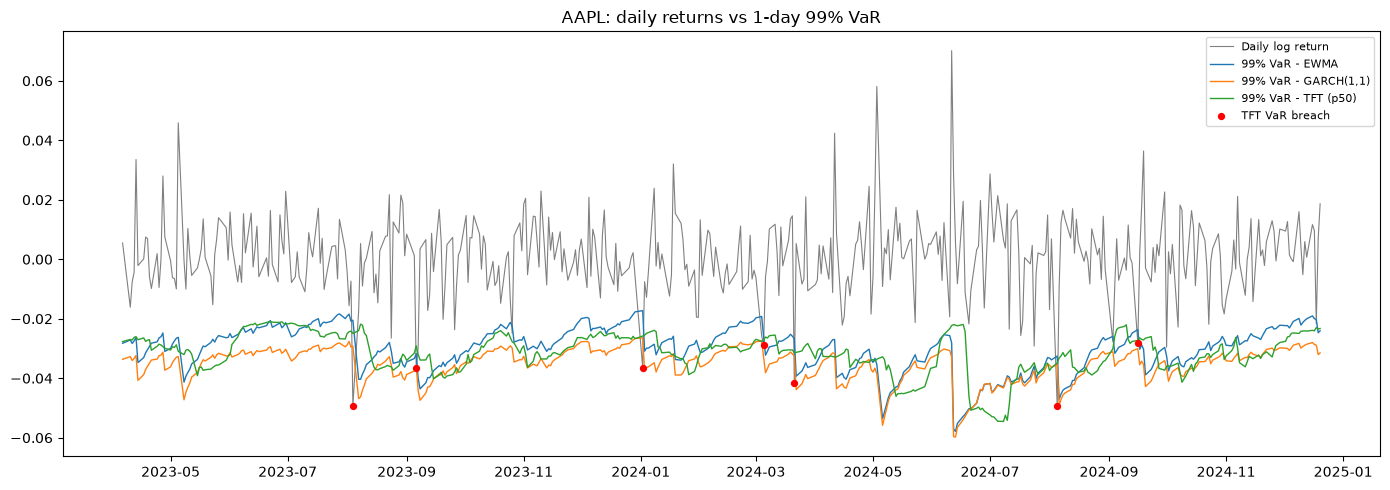

In [ ]:
# CELL V4 - plot one ticker (99% VaR)
T_PLOT = "AAPL"
g = bt[bt["ticker"] == T_PLOT]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(g["date"], g["log_ret"], color="grey", lw=0.8, label="Daily log return")
for name, col in MODELS.items():
    ax.plot(g["date"], norm.ppf(0.01) * g[col], lw=1, label=f"99% VaR - {name}")
exc = g[g["exc_sig_tft_0.01"]]
ax.scatter(exc["date"], exc["log_ret"], color="red", s=18, zorder=3, label="TFT VaR breach")
ax.set_title(f"{T_PLOT}: daily returns vs 1-day 99% VaR")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 10. Upper-band experiment
Uses the TFT's upper band (raw p90, and p90 + rolling-CQR Q) as a conservative σ with normal multipliers. It fixes the 99% level but becomes too conservative at 95%: no single σ fits both levels under a normal distribution, which shows the 99% failures come from the **tail shape** of returns, not the volatility forecast.

In [ ]:
# VaR with conservative sigma from the TFT's upper band:
#   raw p90, and p90 + rolling-CQR Q (both step-0 forecasts, same alignment as sig_tft)
up = test_pts[test_pts["h"] == 0][["ticker", "time_idx", "p90", "Q"]].copy()
up["ticker"]   = up["ticker"].astype(str)
up["time_idx"] = up["time_idx"].astype(int) + TARGET_SHIFT
up["sig_tft_p90"] = up["p90"] / SQRT252
up["sig_tft_cqr"] = (up["p90"] + up["Q"]) / SQRT252

bt2 = bt.merge(up[["ticker", "time_idx", "sig_tft_p90", "sig_tft_cqr"]],
               on=["ticker", "time_idx"], how="left")
print(f"Days with upper-band sigma: {bt2['sig_tft_cqr'].notna().sum():,} of {len(bt2):,}")

MODELS2 = {"TFT (p50)": "sig_tft",
           "TFT (p90)": "sig_tft_p90",
           "TFT (p90 + rolling CQR)": "sig_tft_cqr"}
rows = []
for name, col in MODELS2.items():
    for a in ALPHAS:
        exc = bt2["log_ret"] < norm.ppf(a) * bt2[col]
        for t, g in bt2.assign(exc=exc).groupby("ticker"):
            x, T, lr, p = kupiec(g["exc"], a)
            rows.append({"model": name, "var_level": f"{int((1-a)*100)}%",
                         "exceedances": x, "days": T, "p_value": p})
res = (pd.DataFrame(rows).groupby(["model", "var_level"])
       .agg(days=("days", "sum"), exceedances=("exceedances", "sum"),
            passed=("p_value", lambda s: int((s > 0.05).sum())))
       .reset_index())
res["observed_rate"] = (res["exceedances"] / res["days"]).map("{:.2%}".format)
print(res[["model", "var_level", "observed_rate", "passed"]].to_string(index=False))

Days with upper-band sigma: 21,550 of 21,550
                  model var_level observed_rate  passed
              TFT (p50)       95%         5.24%      47
              TFT (p50)       99%         2.13%      20
TFT (p90 + rolling CQR)       95%         2.89%      18
TFT (p90 + rolling CQR)       99%         1.06%      47
              TFT (p90)       95%         3.55%      31
              TFT (p90)       99%         1.33%      42


## 11. Filtered historical simulation (FHS)
Keeps each model's own σ but replaces the normal multipliers (1.645, 2.326) with empirical quantiles of standardised returns (return ÷ σ) from the previous 250 trading days, pooled across stocks. Real returns are fat-tailed, so the 99% multiplier comes out larger than 2.326, while any consistent bias in a model's σ is cancelled out. Normal VaR is re-scored on the same days for a fair comparison.

In [ ]:
# ── Filtered Historical Simulation (FHS) VaR ──────────────────────────────────
# Keep each model's own daily sigma, but replace the normal multipliers
# (-1.645, -2.326) with EMPIRICAL quantiles of standardised returns z = r / sigma.
# For day t the quantile uses only z from the previous FHS_WINDOW trading days
# (pooled across all stocks) -> no look-ahead. Real z are fat-tailed, so the 99%
# multiplier comes out larger than 2.326 automatically.
FHS_WINDOW = 250   # trading days (~1 year) - fixed in advance, not tuned on test
BURN_IN    = 60    # first days only build the window; not scored

MODELS_FHS = {"EWMA": "sig_ewma", "GARCH(1,1)": "sig_garch", "TFT (p50)": "sig_tft"}

f = bt.sort_values("date").copy()
days = np.sort(f["date"].unique())
f["g"] = pd.Series(np.arange(len(days)), index=days).loc[f["date"]].values
eval_mask = f["g"] >= BURN_IN
g_sorted = f["g"].values                                  # f is sorted by date -> by g

def fhs_multiplier(z, a):
    """Empirical a-quantile of z from days [g-FHS_WINDOW, g-1], for every day g."""
    q = {}
    for g in range(BURN_IN, len(days)):
        lo = np.searchsorted(g_sorted, g - FHS_WINDOW, side="left")
        hi = np.searchsorted(g_sorted, g, side="left")        # strictly before day g
        q[g] = np.quantile(z[lo:hi], a)
    return f["g"].map(q).values

rows, mult_rows = [], []
for name, col in MODELS_FHS.items():
    z = (f["log_ret"] / f[col]).values
    for a in ALPHAS:
        q_emp = fhs_multiplier(z, a)
        for method, var in [("Normal", norm.ppf(a) * f[col].values),
                            ("FHS",    q_emp * f[col].values)]:
            exc = pd.Series(f["log_ret"].values < var, index=f.index)
            sub = f.loc[eval_mask].assign(exc=exc[eval_mask])
            for t, g in sub.groupby("ticker"):
                x, T, lr, p = kupiec(g["exc"], a)
                rows.append({"model": name, "method": method,
                             "var_level": f"{int((1 - a) * 100)}%",
                             "exceedances": x, "days": T, "p_value": p})
        mult_rows.append({"model": name, "var_level": f"{int((1 - a) * 100)}%",
                          "normal_mult": -norm.ppf(a),
                          "fhs_mult_avg": -np.nanmean(q_emp[eval_mask.values])})

fhs_res = (pd.DataFrame(rows).groupby(["model", "var_level", "method"])
           .agg(days=("days", "sum"), exceedances=("exceedances", "sum"),
                passed=("p_value", lambda s: int((s > 0.05).sum())),
                tickers=("p_value", "size"))
           .reset_index())
fhs_res["observed_rate"] = (fhs_res["exceedances"] / fhs_res["days"]).map("{:.2%}".format)

print(f"Evaluation sample: {int(eval_mask.sum()):,} stock-days "
      f"({pd.Timestamp(days[BURN_IN]).date()} to {pd.Timestamp(days[-1]).date()}), "
      f"window {FHS_WINDOW} days, pooled across stocks\n")
print(fhs_res[["model", "var_level", "method", "observed_rate", "passed", "tickers"]]
      .to_string(index=False))
print("\nAverage VaR multiplier (in units of sigma):")
print(pd.DataFrame(mult_rows).round(3).to_string(index=False))

Evaluation sample: 18,550 stock-days (2023-07-05 to 2024-12-20), window 250 days, pooled across stocks

     model var_level method observed_rate  passed  tickers
      EWMA       95%    FHS         5.22%      50       50
      EWMA       95% Normal         5.14%      50       50
      EWMA       99%    FHS         1.14%      50       50
      EWMA       99% Normal         2.23%      27       50
GARCH(1,1)       95%    FHS         5.39%      46       50
GARCH(1,1)       95% Normal         3.57%      38       50
GARCH(1,1)       99%    FHS         1.16%      50       50
GARCH(1,1)       99% Normal         1.32%      49       50
 TFT (p50)       95%    FHS         5.29%      48       50
 TFT (p50)       95% Normal         5.30%      48       50
 TFT (p50)       99%    FHS         1.09%      50       50
 TFT (p50)       99% Normal         2.15%      33       50

Average VaR multiplier (in units of sigma):
     model var_level  normal_mult  fhs_mult_avg
      EWMA       99%        2.326   

## 12. Forecast accuracy benchmark
Compares the TFT's median (p50) volatility forecast with the actual target volatility, against four baselines on exactly the same points: **persistence** (repeat the last known value), **EWMA**, **GARCH(1,1)** and **HAR-RV** (a regression on 1-, 5- and 22-day volatility, fitted on 2018–21).

Every model gets the same information. Because the TFT's encoder has effectively seen realised volatility up to 4 days after its other inputs end (see section 9), each baseline is also given returns up to that day.

- **Metrics:** RMSE, MAE and QLIKE (the standard loss for volatility forecasts); lower is better.
- **Diebold–Mariano test:** whether the TFT's accuracy differs significantly from each baseline (negative statistic = TFT more accurate; p < 0.05 = significant).

In [ ]:
# ── Fair accuracy benchmark for the TFT median (p50) volatility forecast ──────
# Every model gets the SAME information: for a window starting at time_idx k the
# TFT encoder has seen the target up to k-1, i.e. realised vol through day k+4.
# So all baselines use returns up to day o = k+4. Step h predicts target(k+h),
# which is realised vol on day o+1+h (an (h+1)-day-ahead forecast).
#   Persistence : last known realised vol, real_vol(o)
#   EWMA        : ewma_vol(o)                       (flat across horizons)
#   GARCH(1,1)  : 1-day sigma for day o+1, annualised (flat across horizons)
#   HAR-RV      : OLS on 1/5/22-day vol at o, fitted on 2018-2021, one model per h
# Metrics: RMSE, MAE, QLIKE (Patton 2011; on variances, robust to noisy proxies).
from scipy.stats import norm as _norm

key = ["ticker", "time_idx"]
base = df[key + ["date", "log_ret", "real_vol", "ewma_vol"]].copy()
base["ticker"] = base["ticker"].astype(str)
base = base.sort_values(key)

# HAR features at each day (annualised, from returns up to and including that day)
g = base.groupby("ticker")["log_ret"]
base["har_d"] = base["log_ret"].abs() * np.sqrt(252)
base["har_w"] = np.sqrt(g.transform(lambda r: (r**2).rolling(5).mean()) * 252)
base["har_m"] = np.sqrt(g.transform(lambda r: (r**2).rolling(22).mean()) * 252)

# Test points: one row per (window, step), from the rolling-CQR cell
P = test_pts[["ticker", "time_idx", "h", "date", "target", "p50"]].copy()
P["ticker"] = P["ticker"].astype(str)
P["o"] = P["time_idx"] - P["h"] + TARGET_SHIFT - 1          # info day o = k + 4
P = P.merge(base[key + ["real_vol", "ewma_vol", "har_d", "har_w", "har_m"]]
            .rename(columns={"time_idx": "o"}), on=["ticker", "o"], how="left")
gsig = bt[key + ["sig_garch"]].copy(); gsig["ticker"] = gsig["ticker"].astype(str)
gsig["o"] = gsig["time_idx"] - 1                             # sigma for day o+1
P = P.merge(gsig[["ticker", "o", "sig_garch"]], on=["ticker", "o"], how="left")

P["Persistence"] = P["real_vol"]
P["EWMA"]        = P["ewma_vol"]
P["GARCH(1,1)"]  = P["sig_garch"] * SQRT252
P["TFT (p50)"]   = P["p50"]

# HAR-RV: one OLS per horizon, trained only on 2018-2021 (target date <= 2021-12-31)
H = MAX_PREDICTION_LENGTH
X_cols = ["har_d", "har_w", "har_m"]
P["HAR-RV"] = np.nan
for h in range(H):
    tr = base.copy()
    tr["y"]      = tr.groupby("ticker")["real_vol"].shift(-(1 + h))
    tr["y_date"] = tr.groupby("ticker")["date"].shift(-(1 + h))
    tr = tr[(tr["y_date"] <= "2021-12-31")].dropna(subset=X_cols + ["y"])
    A = np.column_stack([np.ones(len(tr)), tr[X_cols].values])
    beta, *_ = np.linalg.lstsq(A, tr["y"].values, rcond=None)
    m = P["h"] == h
    P.loc[m, "HAR-RV"] = np.column_stack([np.ones(m.sum()), P.loc[m, X_cols].values]) @ beta

MODELS_ACC = ["TFT (p50)", "HAR-RV", "Persistence", "EWMA", "GARCH(1,1)"]
P = P.dropna(subset=MODELS_ACC + ["target"])
P = P[(P[MODELS_ACC] > 0).all(axis=1) & (P["target"] > 0)]

def qlike(y, f):                                 # on variances
    r = (y**2) / (f**2)
    return r - np.log(r) - 1

def metrics(sub):
    out = {}
    for mdl in MODELS_ACC:
        e = sub["target"] - sub[mdl]
        out[mdl] = {"RMSE": np.sqrt(np.mean(e**2)), "MAE": np.mean(np.abs(e)),
                    "QLIKE": np.mean(qlike(sub["target"], sub[mdl]))}
    return pd.DataFrame(out).T

print(f"Test points: {len(P):,} ({P['date'].min().date()} to {P['date'].max().date()}), "
      f"{P['ticker'].nunique()} stocks, horizons 1-{H} days\n")
overall = metrics(P)
print("Overall (all horizons):")
print(overall.round(4).to_string())

print("\nRMSE by forecast horizon (days ahead):")
rmse_h = pd.DataFrame({h + 1: metrics(P[P["h"] == h])["RMSE"] for h in range(H)})
print(rmse_h.round(4).to_string())

# Diebold-Mariano test: TFT vs each baseline on squared error.
# Losses averaged across stocks per date (cross-sectional dependence), then a
# Newey-West variance with 20 lags (overlapping 20-day targets).
def dm_test(a, b, lags=20):
    d = (P.assign(d=(P["target"] - P[a])**2 - (P["target"] - P[b])**2)
           .groupby("date")["d"].mean().values)
    n, dbar = len(d), d.mean()
    dc = d - dbar
    lrv = dc @ dc / n + 2 * sum((1 - L / (lags + 1)) * (dc[L:] @ dc[:-L]) / n
                                for L in range(1, lags + 1))
    stat = dbar / np.sqrt(lrv / n)
    return stat, 2 * (1 - _norm.cdf(abs(stat)))

print("\nDiebold-Mariano test, TFT vs baseline (squared error):")
print("  negative statistic = TFT more accurate; p < 0.05 = difference is significant")
for b in MODELS_ACC[1:]:
    s, p = dm_test("TFT (p50)", b)
    verdict = ("TFT better" if s < 0 else "baseline better") if p < 0.05 else "no significant difference"
    print(f"  vs {b:<12} DM = {s:+6.2f}   p = {p:.3f}   -> {verdict}")

Test points: 107,750 (2023-03-30 to 2024-12-19), 50 stocks, horizons 1-5 days

Overall (all horizons):
               RMSE     MAE   QLIKE
TFT (p50)    0.0625  0.0396  0.1351
HAR-RV       0.0480  0.0287  0.0710
Persistence  0.0447  0.0217  0.0657
EWMA         0.0462  0.0293  0.0690
GARCH(1,1)   0.0685  0.0502  0.1251

RMSE by forecast horizon (days ahead):
                  1       2       3       4       5
TFT (p50)    0.0547  0.0586  0.0623  0.0660  0.0699
HAR-RV       0.0342  0.0417  0.0481  0.0536  0.0583
Persistence  0.0250  0.0360  0.0445  0.0519  0.0583
EWMA         0.0399  0.0427  0.0457  0.0491  0.0524
GARCH(1,1)   0.0676  0.0679  0.0684  0.0691  0.0698

Diebold-Mariano test, TFT vs baseline (squared error):
  negative statistic = TFT more accurate; p < 0.05 = difference is significant
  vs HAR-RV       DM =  +7.83   p = 0.000   -> baseline better
  vs Persistence  DM =  +8.78   p = 0.000   -> baseline better
  vs EWMA         DM =  +8.67   p = 0.000   -> baseline better
  vs 